# Model Performance Analysis - Results Folder

This notebook analyzes the performance of different quantized LLMs across multiple benchmarks.

## 📂 Data Source
- **Directory**: `results/` folder in the project root
- **Included**: Model evaluation results (Llama-3.1-8B, Llama-3.2-3B, Llama-3.2-1B)
- **Excluded**: `optimization/` subfolder and `.txt` log files

In [9]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Soft warm color scheme for quantization methods (柔和温暖配色)
QUANT_COLORS = {
    'none': '#D4A574',      # Warm Sand (温暖沙色) - stable warm tone for baseline
    'gptq-4bit': '#F4A261', # Orange (橙色) - vibrant warm orange
    'awq-4bit': '#E76F51',  # Coral (珊瑚色) - energetic coral red
    'bnb-4bit': '#E9C46A'   # Golden Yellow (金黄色) - bright golden yellow
}

# Warm pastel color scheme for datasets (温暖柔和色系)
DATASET_COLORS = {
    'gsm8k': '#F4A261',        # Orange (橙色) - mathematical reasoning
    'truthfulqa': '#E76F51',   # Coral (珊瑚色) - truth-seeking analysis
    'commonsenseqa': '#E9C46A', # Golden Yellow (金黄色) - common sense evaluation
    'humaneval': '#A8DADC',    # Light Blue (浅蓝色) - code evaluation
    'bbh': '#457B9D'           # Ocean Blue (海洋蓝) - big bench evaluation
}

# Marker styles for datasets
DATASET_MARKERS = {
    'gsm8k': 'o',
    'truthfulqa': 's',
    'commonsenseqa': '^',
    'humaneval': 'D',
    'bbh': 'v'
}

# Quantization method display order
QUANT_ORDER = ['none', 'gptq-4bit', 'awq-4bit', 'bnb-4bit']

## 1. Data Loading Functions

**Data Source Directory Structure:**
```
results/
├── Llama-3.2-1B-Instruct/                    ← Baseline (no quantization)
├── Llama-3.2-1B-Instruct-gptq-4bit-.../      ← GPTQ quantized
├── Llama-3.2-1B-Instruct-awq-4bit-.../       ← AWQ quantized
├── Llama-3.2-1B-Instruct-bnb-4bit-.../       ← BitsAndBytes quantized
├── Llama-3.2-3B-Instruct/                    ← Baseline
├── Llama-3.2-3B-Instruct-gptq-4bit-.../
├── Llama-3.2-3B-Instruct-awq-4bit-.../
├── Llama-3.2-3B-Instruct-bnb-4bit-.../
├── Llama-3.1-8B-Instruct/                    ← Baseline
├── Llama-3.1-8B-Instruct-gptq-4bit-.../
├── Llama-3.1-8B-Instruct-awq-4bit-.../
├── Llama-3.1-8B-Instruct-bnb-4bit-.../
├── optimization/                              ⚠️ EXCLUDED
└── *.txt                                      ⚠️ EXCLUDED (log files)
```

Each model directory contains 5 JSON files:
- `gsm8k_results.json`
- `truthfulqa_results.json`
- `commonsenseqa_results.json`
- `humaneval_results.json`
- `bbh_results.json`

In [10]:
def load_all_results(results_dir: str = "results") -> pd.DataFrame:
    """
    Load all result JSON files from the results directory.
    
    IMPORTANT: 
    - Only loads from model directories (e.g., Llama-3.2-3B-Instruct)
    - Excludes 'optimization' folder
    - Excludes .txt log files in results root
    
    Returns a DataFrame with columns:
    - model_name: base model name (e.g., 'Llama-3.2-3B-Instruct')
    - quantization: quantization method (e.g., 'gptq-4bit', 'awq-4bit', 'bnb-4bit', 'none')
    - dataset: dataset name (e.g., 'gsm8k', 'truthfulqa')
    - accuracy: evaluation accuracy
    - gpu_peak_mb: peak GPU memory in MB
    - throughput_tokens_per_sec: generation throughput
    - avg_latency_per_sample: average generation time per sample
    - total_generation_time_sec: total evaluation time
    """
    results = []
    results_path = Path(results_dir)
    
    print(f"📂 Loading results from: {results_path.absolute()}")
    print(f"{'='*80}\n")
    
    # Iterate through all model directories
    for model_dir in results_path.iterdir():
        # Skip non-directories
        if not model_dir.is_dir():
            continue
        
        # Skip optimization directory (explicitly excluded)
        if model_dir.name == "optimization":
            print(f"⏭️  Skipping: {model_dir.name} (optimization folder - excluded)")
            continue
        
        print(f"📁 Processing: {model_dir.name}")
        
        # Parse model name and quantization method
        dir_name = model_dir.name
        
        # Extract quantization info
        if "gptq" in dir_name.lower():
            quantization = "gptq-4bit"
            model_name = dir_name.split("-gptq")[0]
        elif "awq" in dir_name.lower():
            quantization = "awq-4bit"
            model_name = dir_name.split("-awq")[0]
        elif "bnb" in dir_name.lower():
            quantization = "bnb-4bit"
            model_name = dir_name.split("-bnb")[0]
        else:
            quantization = "none"
            model_name = dir_name
        
        # Load all dataset results in this directory
        json_files = list(model_dir.glob("*_results.json"))
        
        if not json_files:
            print(f"   ⚠️  No JSON files found in {model_dir.name}")
            continue
        
        for json_file in json_files:
            dataset = json_file.stem.replace("_results", "")
            
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Calculate average latency per sample
                total_time = data.get("total_generation_time_sec", 0)
                total_samples = data.get("total", 1)
                avg_latency = total_time / total_samples if total_samples > 0 else 0
                
                results.append({
                    "model_name": model_name,
                    "quantization": quantization,
                    "dataset": dataset,
                    "accuracy": data.get("accuracy", data.get("pass@1", 0)),
                    "gpu_peak_mb": data.get("gpu_peak_mb", 0),
                    "throughput_tokens_per_sec": data.get("throughput_tokens_per_sec", 0),
                    "avg_latency_per_sample": avg_latency,
                    "total_generation_time_sec": total_time,
                    "total_samples": total_samples,
                    "correct": data.get("correct", 0),
                    "model_path": data.get("model_path", "")
                })
                
                print(f"   ✓ Loaded: {dataset} (accuracy={data.get('accuracy', 0):.4f})")
                
            except Exception as e:
                print(f"   ❌ Error loading {json_file.name}: {e}")
    
    df = pd.DataFrame(results)
    
    # Create a combined identifier for easier plotting
    df['model_id'] = df['model_name'] + ' (' + df['quantization'] + ')'
    
    print(f"\n{'='*80}")
    print(f"✅ Data loading complete!")
    print(f"   Total records: {len(df)}")
    print(f"   Unique models: {df['model_name'].nunique()}")
    print(f"   Unique quantization methods: {df['quantization'].nunique()}")
    print(f"   Unique datasets: {df['dataset'].nunique()}")
    print(f"{'='*80}\n")
    
    return df


def get_model_size(model_name: str) -> str:
    """
    Extract model size from model name (e.g., '3B', '8B', '1B').
    """
    if "8B" in model_name:
        return "8B"
    elif "3B" in model_name:
        return "3B"
    elif "1B" in model_name:
        return "1B"
    else:
        return "Unknown"

In [11]:
# Load all results from the 'results' folder (excluding 'optimization' subdirectory)
df = load_all_results(results_dir="results")
df['model_size'] = df['model_name'].apply(get_model_size)

# Display data overview
print("\n📊 Data Overview:")
print(f"{'='*80}")
print(f"\n🔹 Models found:")
for model in sorted(df['model_name'].unique()):
    count = len(df[df['model_name'] == model])
    print(f"   • {model}: {count} records")

print(f"\n🔹 Quantization methods:")
for quant in sorted(df['quantization'].unique()):
    count = len(df[df['quantization'] == quant])
    print(f"   • {quant}: {count} records")

print(f"\n🔹 Datasets:")
for dataset in sorted(df['dataset'].unique()):
    count = len(df[df['dataset'] == dataset])
    avg_acc = df[df['dataset'] == dataset]['accuracy'].mean()
    print(f"   • {dataset}: {count} records (avg accuracy: {avg_acc:.4f})")

print(f"\n{'='*80}\n")

# Display sample data
print("Sample data (first 10 rows):")
df[['model_name', 'quantization', 'dataset', 'accuracy', 'gpu_peak_mb', 'avg_latency_per_sample']].head(10)

📂 Loading results from: /home/claire/Documents/Green_AI/results

📁 Processing: Llama-3.2-3B-Instruct-bnb-4bit-20251118_030711
   ✓ Loaded: gsm8k (accuracy=0.6566)
   ✓ Loaded: commonsenseqa (accuracy=0.6896)
   ✓ Loaded: humaneval (accuracy=0.0000)
   ✓ Loaded: bbh (accuracy=0.5690)
   ✓ Loaded: truthfulqa (accuracy=0.4247)
📁 Processing: Llama-3.2-3B-Instruct
   ✓ Loaded: gsm8k (accuracy=0.6785)
   ✓ Loaded: commonsenseqa (accuracy=0.7109)
   ✓ Loaded: humaneval (accuracy=0.0000)
   ✓ Loaded: bbh (accuracy=0.5942)
   ✓ Loaded: truthfulqa (accuracy=0.4455)
📁 Processing: Llama-3.2-3B-Instruct-awq-4bit-20251109_012853
   ✓ Loaded: gsm8k (accuracy=0.6740)
   ✓ Loaded: commonsenseqa (accuracy=0.6945)
   ✓ Loaded: humaneval (accuracy=0.0000)
   ✓ Loaded: bbh (accuracy=0.5763)
   ✓ Loaded: truthfulqa (accuracy=0.4602)
📁 Processing: Llama-3.1-8B-Instruct
   ✓ Loaded: gsm8k (accuracy=0.7657)
   ✓ Loaded: commonsenseqa (accuracy=0.7789)
   ✓ Loaded: humaneval (accuracy=0.0000)
   ✓ Loaded: bbh (

,model_name,quantization,dataset,accuracy,gpu_peak_mb,avg_latency_per_sample
0,Llama-3.2-3B-Instruct,bnb-4bit,gsm8k,0.656558,2393.9297,1.649780
1,Llama-3.2-3B-Instruct,bnb-4bit,commonsenseqa,0.689599,2274.1968,0.047489
2,Llama-3.2-3B-Instruct,bnb-4bit,humaneval,0.981707,3674.0361,5.465232
3,Llama-3.2-3B-Instruct,bnb-4bit,bbh,0.569037,2357.5576,3.580886
4,Llama-3.2-3B-Instruct,bnb-4bit,truthfulqa,0.424725,2237.1626,1.413795
5,Llama-3.2-3B-Instruct,none,gsm8k,0.678544,6348.5156,1.134199
6,Llama-3.2-3B-Instruct,none,commonsenseqa,0.710893,6226.4126,0.035083
7,Llama-3.2-3B-Instruct,none,humaneval,0.963415,6278.4883,3.622301
8,Llama-3.2-3B-Instruct,none,bbh,0.594225,6348.8232,2.418143
9,Llama-3.2-3B-Instruct,none,truthfulqa,0.445532,6183.0962,0.950694


In [12]:
# Data Validation & Summary

print("🔍 Data Validation Check:")
print("="*80)

# Check for missing values
print("\n1. Missing Values Check:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    print(missing[missing > 0])

# Check data completeness by model
print("\n2. Model-Quantization-Dataset Completeness:")
print("\nExpected: Each (model, quantization) pair should have 5 datasets")
completeness = df.groupby(['model_name', 'quantization']).size().reset_index(name='dataset_count')
print(completeness)

incomplete = completeness[completeness['dataset_count'] != 5]
if len(incomplete) > 0:
    print("\n⚠️  Incomplete records (missing some datasets):")
    print(incomplete)
else:
    print("\n✓ All model-quantization pairs have complete dataset coverage")

# Summary statistics
print("\n3. Summary Statistics:")
summary_stats = df.groupby('quantization').agg({
    'accuracy': ['mean', 'std', 'min', 'max'],
    'gpu_peak_mb': ['mean', 'std', 'min', 'max'],
    'avg_latency_per_sample': ['mean', 'std', 'min', 'max']
}).round(4)
print(summary_stats)

print("\n" + "="*80)

🔍 Data Validation Check:

1. Missing Values Check:
   ✓ No missing values found

2. Model-Quantization-Dataset Completeness:

Expected: Each (model, quantization) pair should have 5 datasets
               model_name quantization  dataset_count
0   Llama-3.1-8B-Instruct     awq-4bit              5
1   Llama-3.1-8B-Instruct     bnb-4bit              5
2   Llama-3.1-8B-Instruct    gptq-4bit              5
3   Llama-3.1-8B-Instruct         none              5
4   Llama-3.2-1B-Instruct     awq-4bit              5
5   Llama-3.2-1B-Instruct     bnb-4bit              5
6   Llama-3.2-1B-Instruct    gptq-4bit              5
7   Llama-3.2-1B-Instruct         none              5
8   Llama-3.2-3B-Instruct     awq-4bit              5
9   Llama-3.2-3B-Instruct     bnb-4bit              5
10  Llama-3.2-3B-Instruct    gptq-4bit              5
11  Llama-3.2-3B-Instruct         none              5

✓ All model-quantization pairs have complete dataset coverage

3. Summary Statistics:
             accurac

## 2. Cross-Model Comparison

Compare GPU peak memory, accuracy, and latency across different models.

In [13]:
# Aggregate metrics across all datasets for each model configuration
model_summary = df.groupby(['model_name', 'quantization', 'model_id']).agg({
    'accuracy': 'mean',
    'gpu_peak_mb': 'mean',
    'avg_latency_per_sample': 'mean',
    'throughput_tokens_per_sec': 'mean'
}).reset_index()

model_summary

,model_name,quantization,model_id,accuracy,gpu_peak_mb,avg_latency_per_sample,throughput_tokens_per_sec
0,Llama-3.1-8B-Instruct,awq-4bit,Llama-3.1-8B-Instruct (awq-4bit),0.732215,5663.97228,2.856911,873.49708
1,Llama-3.1-8B-Instruct,bnb-4bit,Llama-3.1-8B-Instruct (bnb-4bit),0.749756,9816.87880,2.837503,1186.96534
2,Llama-3.1-8B-Instruct,gptq-4bit,Llama-3.1-8B-Instruct (gptq-4bit),0.742243,5750.11972,5.583470,787.89268
3,Llama-3.1-8B-Instruct,none,Llama-3.1-8B-Instruct (none),0.754828,15499.07032,3.181645,1449.86486
4,Llama-3.2-1B-Instruct,awq-4bit,Llama-3.2-1B-Instruct (awq-4bit),0.483656,1059.16242,1.361022,3282.10834
5,Llama-3.2-1B-Instruct,bnb-4bit,Llama-3.2-1B-Instruct (bnb-4bit),0.474562,1198.70750,1.543781,3251.36084
6,Llama-3.2-1B-Instruct,gptq-4bit,Llama-3.2-1B-Instruct (gptq-4bit),0.420165,1080.28974,1.293311,4127.71656
7,Llama-3.2-1B-Instruct,none,Llama-3.2-1B-Instruct (none),0.480029,2429.70986,0.690994,6240.08166
8,Llama-3.2-3B-Instruct,awq-4bit,Llama-3.2-3B-Instruct (awq-4bit),0.674899,2314.35098,2.464965,1544.24550
9,Llama-3.2-3B-Instruct,bnb-4bit,Llama-3.2-3B-Instruct (bnb-4bit),0.664325,2587.37656,2.431436,2089.10584


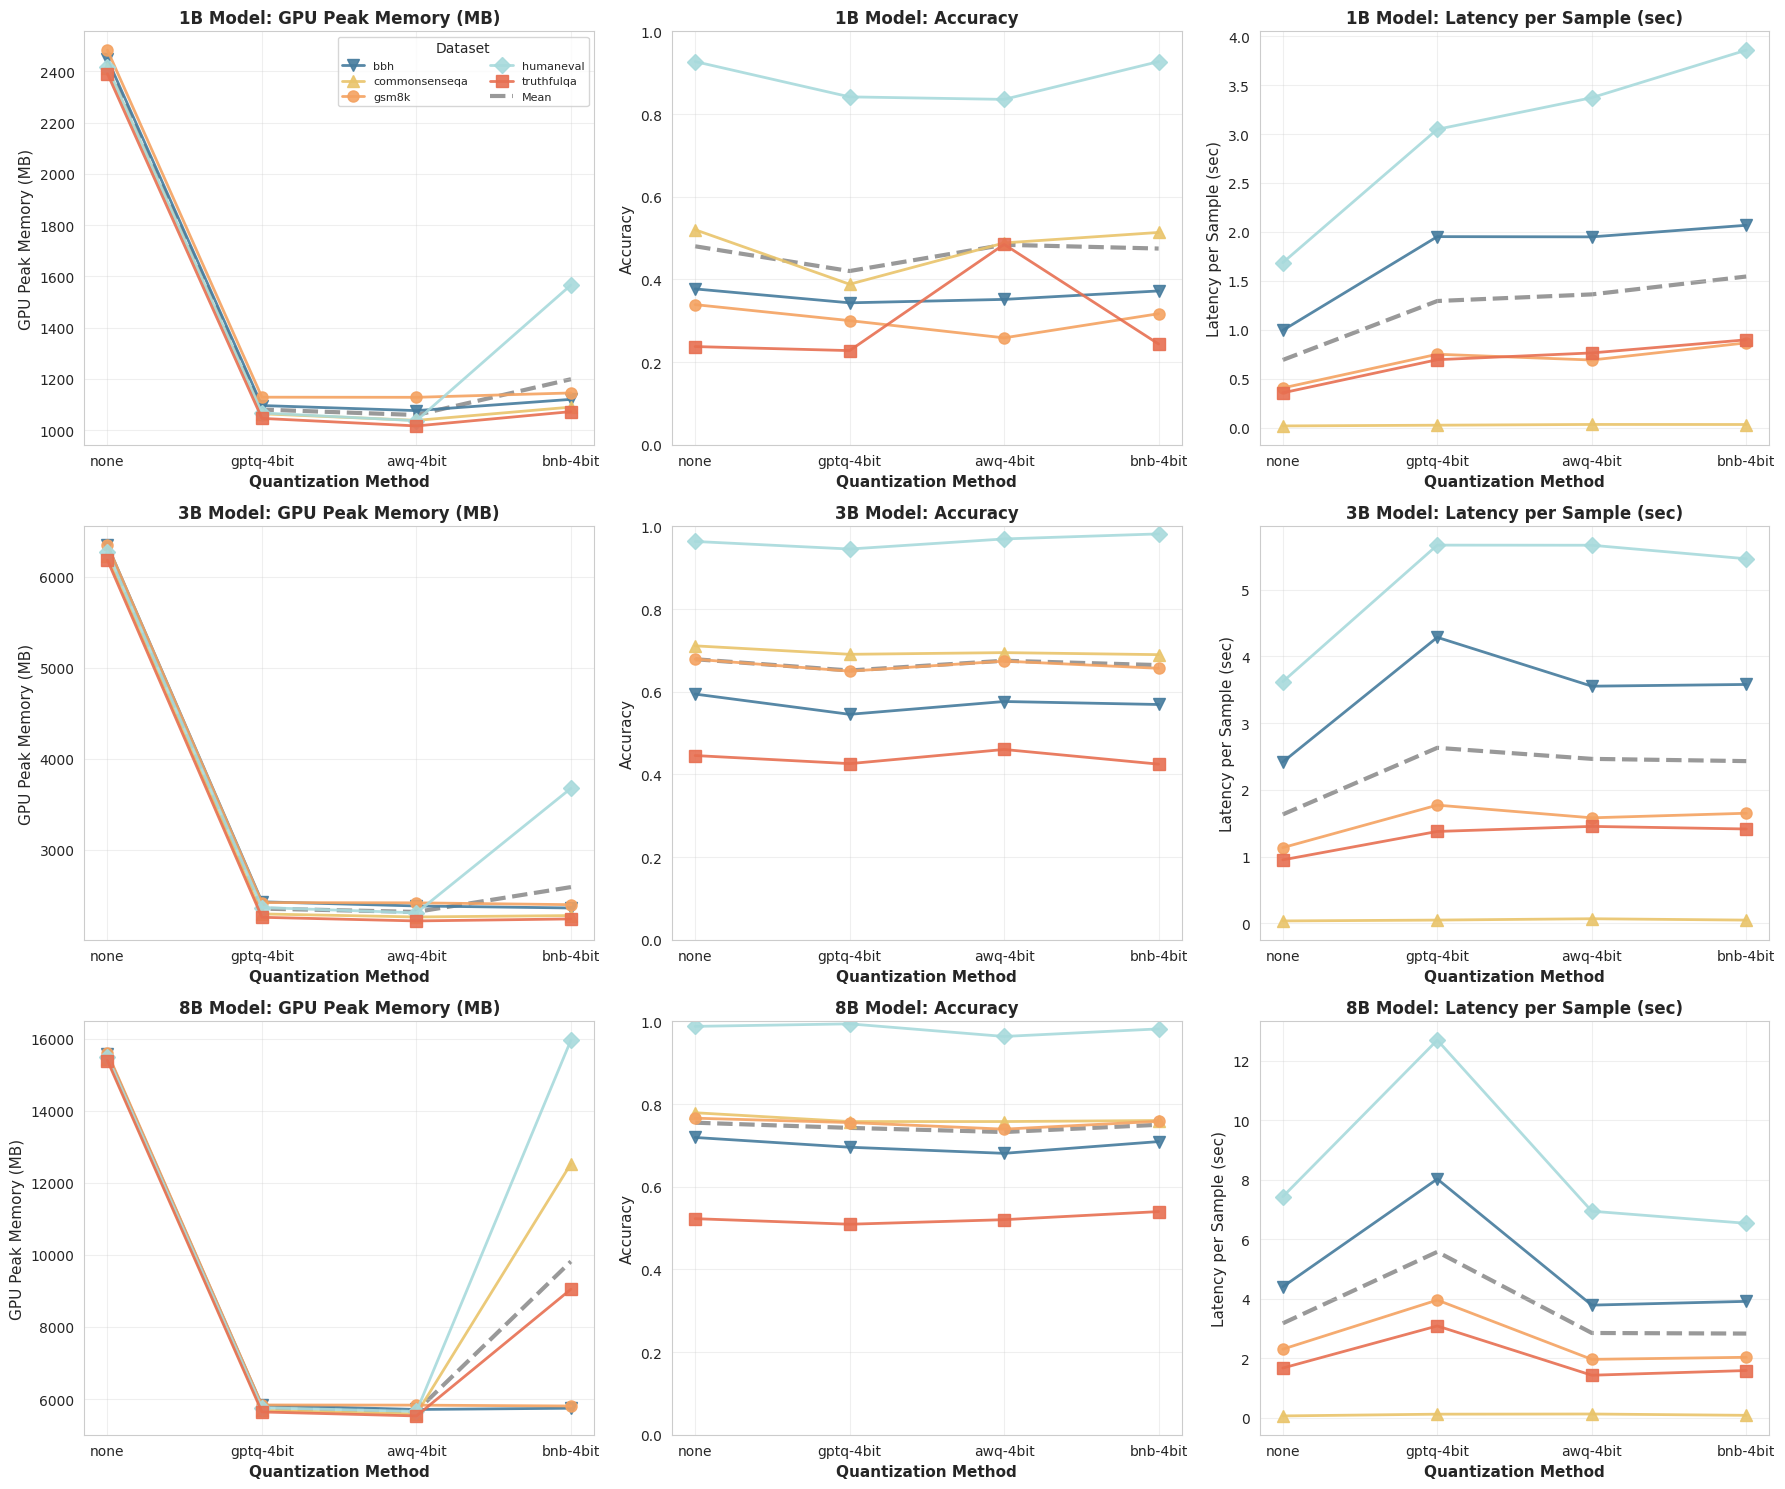

In [14]:
# Visualization: Performance Comparison by Model Size
# X-axis: Quantization methods | Points: Different datasets

model_sizes = sorted(df['model_size'].unique())
metrics = ['gpu_peak_mb', 'accuracy', 'avg_latency_per_sample']
metric_labels = ['GPU Peak Memory (MB)', 'Accuracy', 'Latency per Sample (sec)']

fig, axes = plt.subplots(len(model_sizes), len(metrics), figsize=(18, 5*len(model_sizes)))

# If only one model size, reshape axes
if len(model_sizes) == 1:
    axes = axes.reshape(1, -1)

for i, model_size in enumerate(model_sizes):
    df_size = df[df['model_size'] == model_size]
    
    for j, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[i, j] if len(model_sizes) > 1 else axes[j]
        
        # For each dataset, plot points across quantization methods
        for dataset in sorted(df_size['dataset'].unique()):
            df_dataset = df_size[df_size['dataset'] == dataset]
            
            # Sort by quantization order
            quant_values = []
            quants = []
            for quant in QUANT_ORDER:
                df_point = df_dataset[df_dataset['quantization'] == quant]
                if len(df_point) > 0:
                    quant_values.append(df_point[metric].values[0])
                    quants.append(quant)
                else:
                    quant_values.append(np.nan)
                    quants.append(quant)
            
            # Plot line with markers for each dataset
            ax.plot(quants, quant_values,
                   marker=DATASET_MARKERS.get(dataset, 'o'),
                   color=DATASET_COLORS.get(dataset, 'gray'),
                   linewidth=2, markersize=8, alpha=0.9,
                   label=dataset)
        
        # Calculate and plot mean values
        mean_values = []
        for quant in QUANT_ORDER:
            df_quant = df_size[df_size['quantization'] == quant]
            if len(df_quant) > 0:
                mean_values.append(df_quant[metric].mean())
            else:
                mean_values.append(np.nan)
        
        # Plot mean as thick line
        ax.plot(QUANT_ORDER, mean_values, 
               color='black', linewidth=3, alpha=0.4,
               linestyle='--', label='Mean', zorder=0)
        
        # Formatting
        ax.set_xlabel('Quantization Method', fontsize=11, fontweight='bold')
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(f'{model_size} Model: {label}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=0)
        
        if metric == 'accuracy':
            ax.set_ylim([0, 1])
        
        # Add legend only on first plot
        if i == 0 and j == 0:
            ax.legend(title='Dataset', loc='best', fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


## 3. Cross-Dataset Analysis

Analyze how the same model performs across different datasets.

In [15]:
# Select a few models to analyze
models_to_analyze = df['model_id'].unique()[:4]  # Analyze first 4 models
print(f"Analyzing models: {list(models_to_analyze)}")

# Filter data
df_subset = df[df['model_id'].isin(models_to_analyze)]

Analyzing models: ['Llama-3.2-3B-Instruct (bnb-4bit)', 'Llama-3.2-3B-Instruct (none)', 'Llama-3.2-3B-Instruct (awq-4bit)', 'Llama-3.1-8B-Instruct (none)']


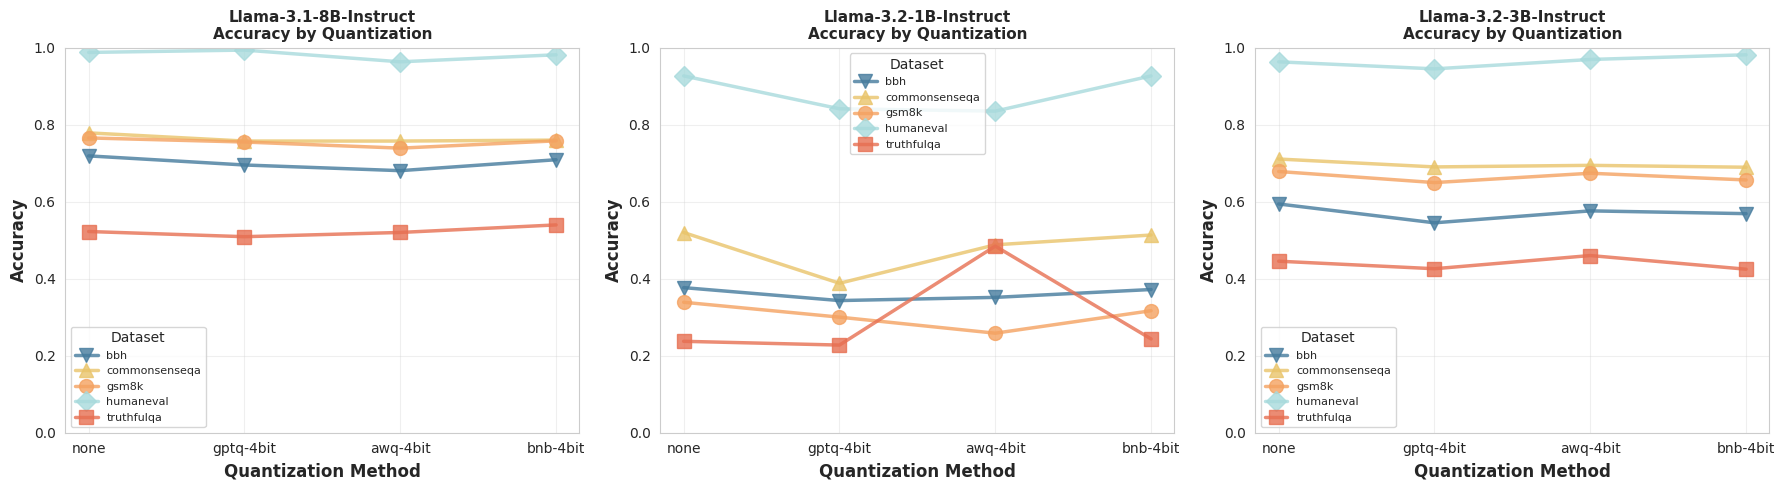

In [16]:
# Accuracy across quantization methods - Line plot with markers
# X-axis: Quantization methods | Lines: Datasets
# Each subplot = one base model

base_models = sorted(df['model_name'].unique())
datasets_list = sorted(df['dataset'].unique())

fig, axes = plt.subplots(1, len(base_models), figsize=(6*len(base_models), 5))

# If only one model, make axes iterable
if len(base_models) == 1:
    axes = [axes]

for i, model in enumerate(base_models):
    ax = axes[i]
    df_model = df[df['model_name'] == model]
    
    # Plot each dataset as a line across quantization methods
    for dataset in datasets_list:
        df_dataset = df_model[df_model['dataset'] == dataset]
        
        # Prepare data: ensure we have all quantization methods in order
        accuracies = []
        for quant in QUANT_ORDER:
            acc = df_dataset[df_dataset['quantization'] == quant]['accuracy']
            if len(acc) > 0:
                accuracies.append(acc.values[0])
            else:
                accuracies.append(np.nan)
        
        # Plot line with markers
        ax.plot(QUANT_ORDER, accuracies, 
               marker=DATASET_MARKERS.get(dataset, 'o'), 
               markersize=10, linewidth=2.5, alpha=0.8,
               color=DATASET_COLORS.get(dataset, 'gray'),
               label=dataset)
    
    ax.set_xlabel('Quantization Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title(f'{model}\nAccuracy by Quantization', fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend(title='Dataset', loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

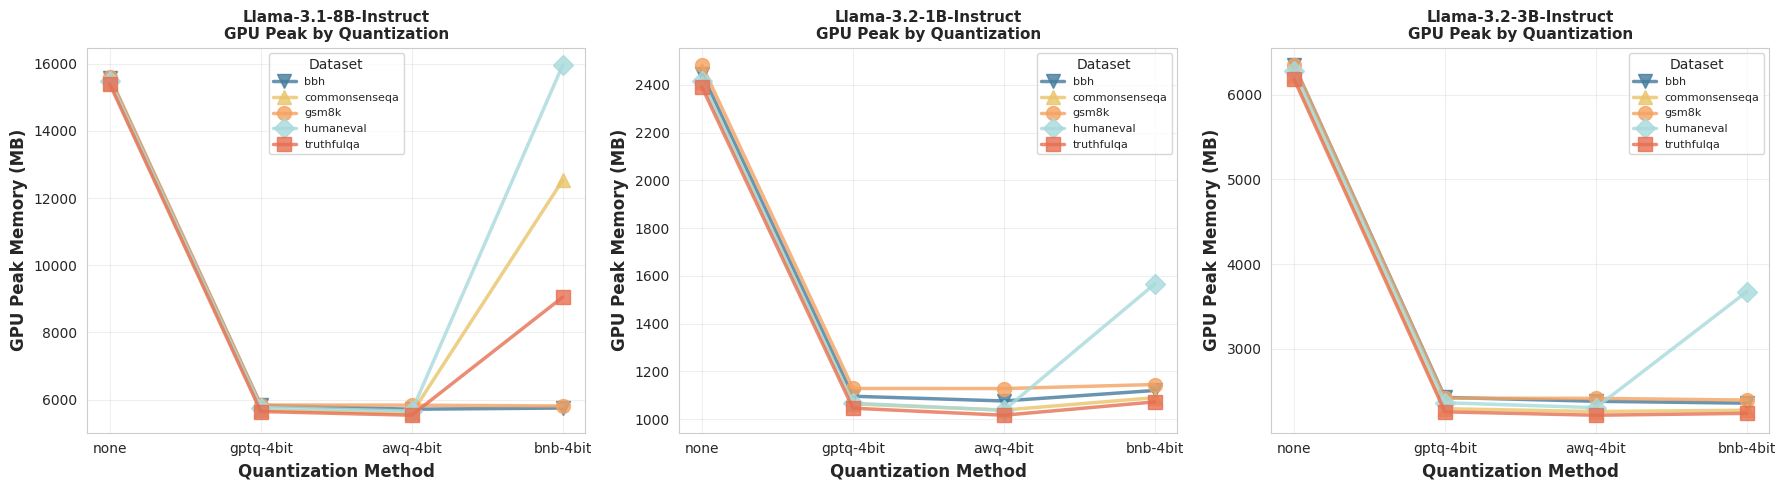

In [17]:
# GPU Peak Memory across quantization methods - Line plot with markers
# X-axis: Quantization methods | Lines: Datasets

fig, axes = plt.subplots(1, len(base_models), figsize=(6*len(base_models), 5))

# If only one model, make axes iterable
if len(base_models) == 1:
    axes = [axes]

for i, model in enumerate(base_models):
    ax = axes[i]
    df_model = df[df['model_name'] == model]
    
    # Plot each dataset as a line across quantization methods
    for dataset in datasets_list:
        df_dataset = df_model[df_model['dataset'] == dataset]
        
        # Prepare data
        gpu_peaks = []
        for quant in QUANT_ORDER:
            gpu = df_dataset[df_dataset['quantization'] == quant]['gpu_peak_mb']
            if len(gpu) > 0:
                gpu_peaks.append(gpu.values[0])
            else:
                gpu_peaks.append(np.nan)
        
        # Plot line with markers
        ax.plot(QUANT_ORDER, gpu_peaks, 
               marker=DATASET_MARKERS.get(dataset, 'o'), 
               markersize=10, linewidth=2.5, alpha=0.8,
               color=DATASET_COLORS.get(dataset, 'gray'),
               label=dataset)
    
    ax.set_xlabel('Quantization Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('GPU Peak Memory (MB)', fontsize=12, fontweight='bold')
    ax.set_title(f'{model}\nGPU Peak by Quantization', fontsize=11, fontweight='bold')
    ax.legend(title='Dataset', loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


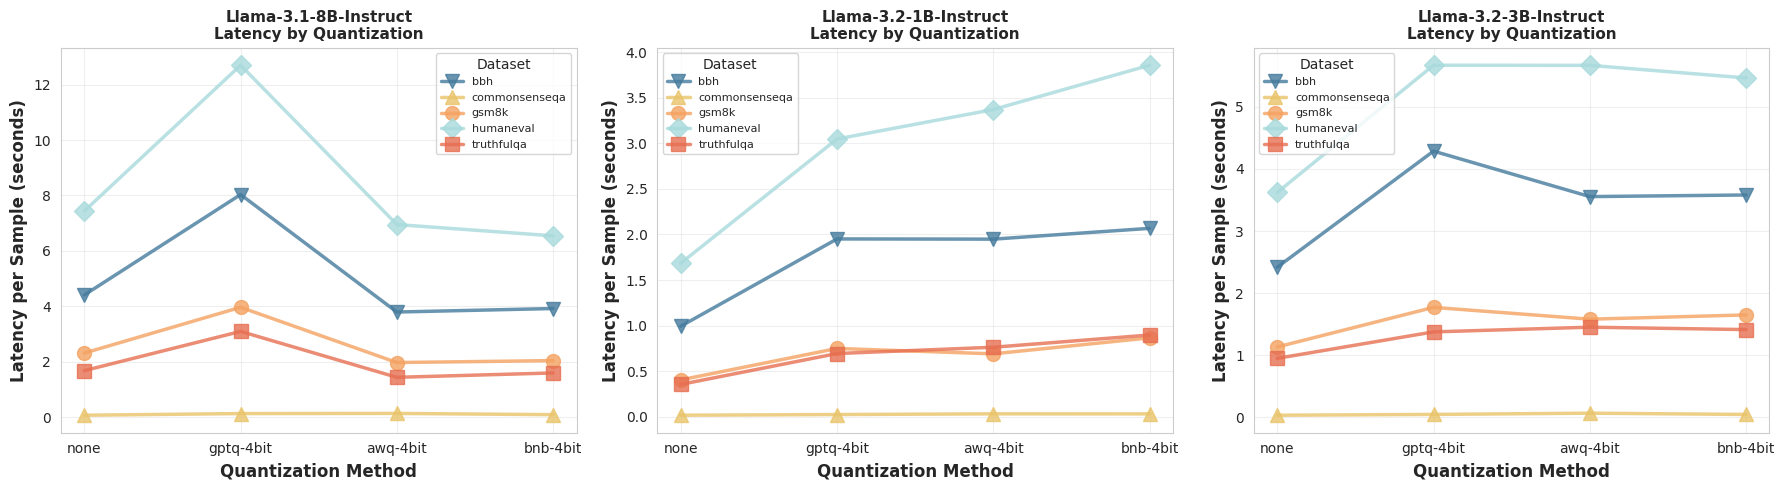

In [18]:
# Latency across quantization methods - Line plot with markers
# X-axis: Quantization methods | Lines: Datasets

fig, axes = plt.subplots(1, len(base_models), figsize=(6*len(base_models), 5))

# If only one model, make axes iterable
if len(base_models) == 1:
    axes = [axes]

for i, model in enumerate(base_models):
    ax = axes[i]
    df_model = df[df['model_name'] == model]
    
    # Plot each dataset as a line across quantization methods
    for dataset in datasets_list:
        df_dataset = df_model[df_model['dataset'] == dataset]
        
        # Prepare data
        latencies = []
        for quant in QUANT_ORDER:
            lat = df_dataset[df_dataset['quantization'] == quant]['avg_latency_per_sample']
            if len(lat) > 0:
                latencies.append(lat.values[0])
            else:
                latencies.append(np.nan)
        
        # Plot line with markers
        ax.plot(QUANT_ORDER, latencies, 
               marker=DATASET_MARKERS.get(dataset, 'o'), 
               markersize=10, linewidth=2.5, alpha=0.8,
               color=DATASET_COLORS.get(dataset, 'gray'),
               label=dataset)
    
    ax.set_xlabel('Quantization Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('Latency per Sample (seconds)', fontsize=12, fontweight='bold')
    ax.set_title(f'{model}\nLatency by Quantization', fontsize=11, fontweight='bold')
    ax.legend(title='Dataset', loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

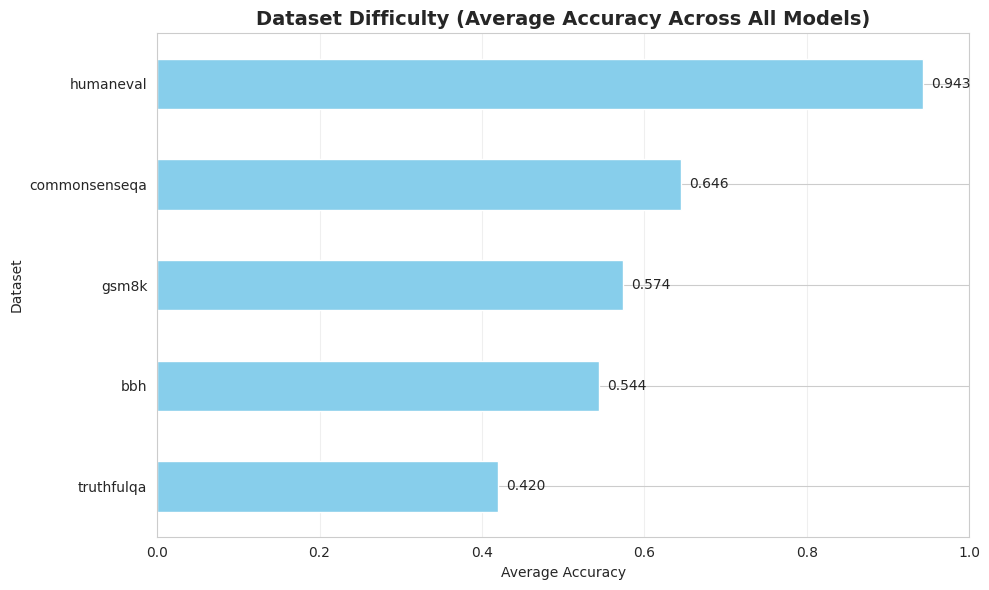

In [19]:
# Heatmap: Dataset difficulty (average accuracy across all models)
dataset_difficulty = df.groupby('dataset')['accuracy'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
dataset_difficulty.plot(kind='barh', ax=ax, color='skyblue')

ax.set_title('Dataset Difficulty (Average Accuracy Across All Models)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Accuracy')
ax.set_ylabel('Dataset')
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(dataset_difficulty):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

📊 Baseline Performance (No Quantization):
                   Model  Baseline Accuracy  Baseline GPU Peak (MB)  \
0  Llama-3.1-8B-Instruct             0.7548              15605.4746   
1  Llama-3.2-1B-Instruct             0.4800               2482.3633   
2  Llama-3.2-3B-Instruct             0.6785               6348.8232   

   Baseline Total Time (sec)  
0                 34434.5385  
1                  7589.9243  
2                 18654.1475  

📈 Percentage Changes from Baseline:
                   Model Quantization  Accuracy Change (%)  \
0  Llama-3.2-3B-Instruct    gptq-4bit                -4.01   
1  Llama-3.2-3B-Instruct     awq-4bit                -0.53   
2  Llama-3.2-3B-Instruct     bnb-4bit                -2.09   
3  Llama-3.1-8B-Instruct    gptq-4bit                -1.67   
4  Llama-3.1-8B-Instruct     awq-4bit                -3.00   
5  Llama-3.1-8B-Instruct     bnb-4bit                -0.67   
6  Llama-3.2-1B-Instruct    gptq-4bit               -12.47   
7  Llama-3.2-1B-

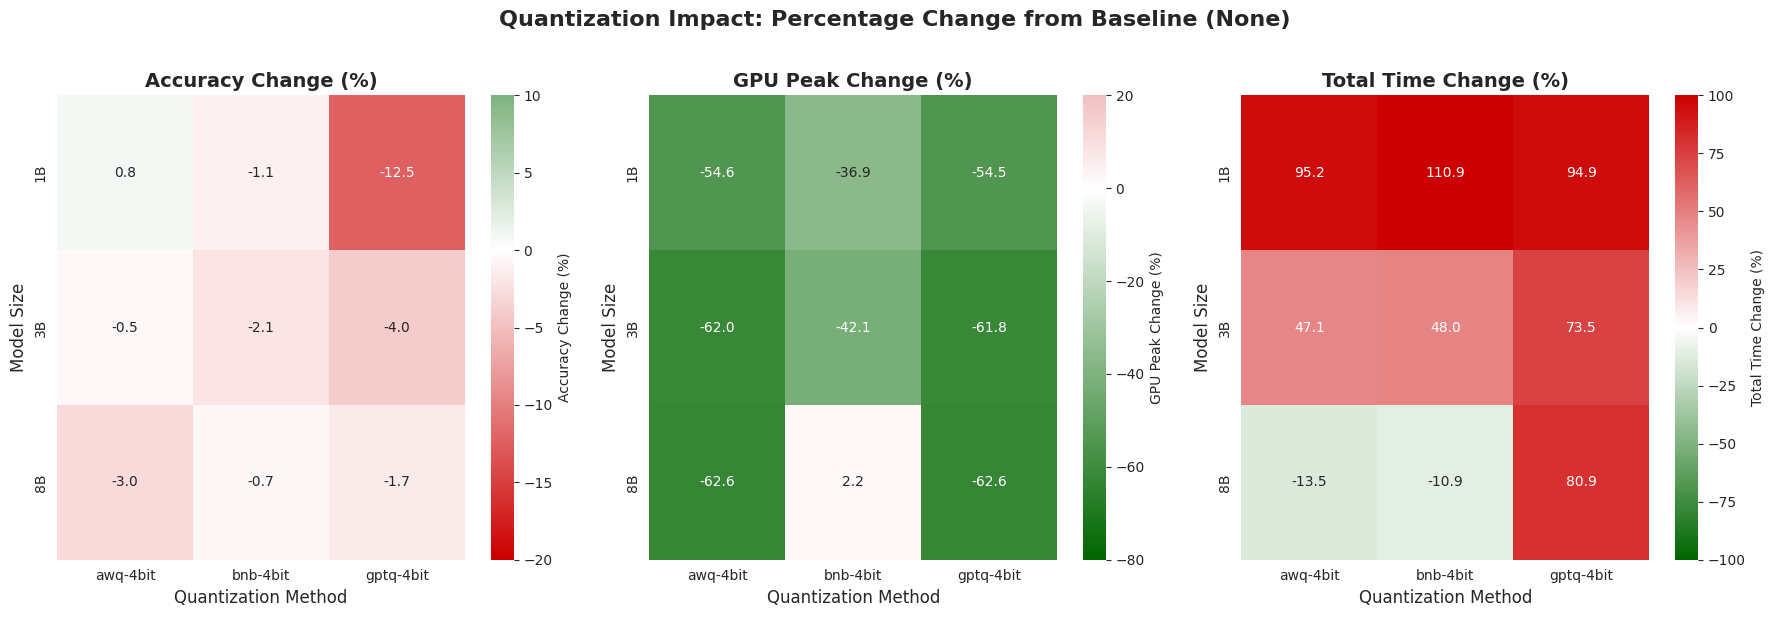

In [20]:
# Quantization Impact Analysis: Percentage Change from Baseline
# 量化影響分析：相對於基準線的百分比變化

import matplotlib.colors as mcolors

# Calculate baseline values for each model
baseline_data = df[df['quantization'] == 'none'].groupby('model_name').agg({
    'accuracy': 'mean',  # Average accuracy across datasets
    'gpu_peak_mb': 'max',  # Maximum GPU peak memory
    'total_generation_time_sec': 'sum'  # Sum of total generation time across all datasets
}).reset_index()

print("📊 Baseline Performance (No Quantization):")
print("="*80)
baseline_data.columns = ['Model', 'Baseline Accuracy', 'Baseline GPU Peak (MB)', 'Baseline Total Time (sec)']
print(baseline_data.round(4))
print()

# Calculate percentage changes for each quantized model
quant_changes = []

for model in df['model_name'].unique():
    baseline = baseline_data[baseline_data['Model'] == model]
    if len(baseline) == 0:
        continue
    
    baseline_acc = baseline['Baseline Accuracy'].values[0]
    baseline_gpu = baseline['Baseline GPU Peak (MB)'].values[0]
    baseline_time = baseline['Baseline Total Time (sec)'].values[0]
    
    for quant in ['gptq-4bit', 'awq-4bit', 'bnb-4bit']:
        quant_data = df[(df['model_name'] == model) & (df['quantization'] == quant)]
        if len(quant_data) == 0:
            continue
        
        # Calculate metrics as specified
        quant_acc = quant_data['accuracy'].mean()  # Average accuracy
        quant_gpu = quant_data['gpu_peak_mb'].max()  # Maximum GPU peak
        quant_time = quant_data['total_generation_time_sec'].sum()  # Sum of total time
        
        # Calculate percentage changes
        acc_change = ((quant_acc - baseline_acc) / baseline_acc) * 100
        gpu_change = ((quant_gpu - baseline_gpu) / baseline_gpu) * 100
        time_change = ((quant_time - baseline_time) / baseline_time) * 100
        
        quant_changes.append({
            'Model': model,
            'Quantization': quant,
            'Accuracy Change (%)': acc_change,
            'GPU Peak Change (%)': gpu_change,
            'Total Time Change (%)': time_change
        })

changes_df = pd.DataFrame(quant_changes)
print("📈 Percentage Changes from Baseline:")
print("="*80)
print(changes_df.round(2))
print()

# Create heatmap visualization
if len(changes_df) > 0:
    # Prepare data for heatmap - simplify model names to sizes only
    changes_df_heatmap = changes_df.copy()
    changes_df_heatmap['Model_Size'] = changes_df_heatmap['Model'].apply(
        lambda x: '8B' if '8B' in x else ('3B' if '3B' in x else ('1B' if '1B' in x else x))
    )
    
    # Prepare data for heatmap
    metrics = ['Accuracy Change (%)', 'GPU Peak Change (%)', 'Total Time Change (%)']
    
    # Create pivot tables for each metric
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Quantization Impact: Percentage Change from Baseline (None)', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # Create pivot table using simplified model names
        pivot_data = changes_df_heatmap.pivot(index='Model_Size', columns='Quantization', values=metric)
        
        # Define color map based on metric - deeper colors like DataFrame
        if 'Accuracy' in metric:
            # Red for accuracy loss, green for accuracy gain - deeper colors
            cmap = mcolors.LinearSegmentedColormap.from_list("", ["#CC0000", "#FFFFFF", "#006600"])
            vmin, vmax = -20, 10  # Expected range for accuracy changes
        elif 'GPU' in metric:
            # Green for memory reduction, red for memory increase - deeper colors
            cmap = mcolors.LinearSegmentedColormap.from_list("", ["#006600", "#FFFFFF", "#CC0000"])
            vmin, vmax = -80, 20  # Expected range for GPU changes
        else:  # Time
            # Green for time reduction, red for time increase - deeper colors
            cmap = mcolors.LinearSegmentedColormap.from_list("", ["#006600", "#FFFFFF", "#CC0000"])
            vmin, vmax = -100, 100  # Expanded range for time changes
        
        # Create heatmap
        sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap=cmap, 
                   center=0, vmin=vmin, vmax=vmax, ax=ax,
                   cbar_kws={'label': f'{metric}'})
        
        ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Quantization Method', fontsize=12)
        ax.set_ylabel('Model Size', fontsize=12)
        
        # Rotate x-axis labels
        ax.tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()

In [21]:
# DataFrame version with gradient color coding (Red-Green Gradient)
print("\n" + "="*100)
print("📋 DataFrame Version with Gradient Color Coding (Red-Green)")
print("="*100)

def create_gradient_styler_simple(df, metric_name):
    """
    Create gradient styling for DataFrame based on metric type - Simple Red-Green (Deeper Colors)
    """
    if 'Accuracy' in metric_name:
        # Red for accuracy loss, green for accuracy gain - deeper colors
        cmap = ['#CC0000', '#FFFFFF', '#006600']  # Dark red -> White -> Dark green
        vmin, vmax = -20, 10
    elif 'GPU' in metric_name:
        # Green for memory reduction, red for memory increase - deeper colors
        cmap = ['#006600', '#FFFFFF', '#CC0000']  # Dark green -> White -> Dark red
        vmin, vmax = -80, 20
    else:  # Time
        # Green for time reduction, red for time increase - deeper colors
        cmap = ['#006600', '#FFFFFF', '#CC0000']  # Dark green -> White -> Dark red
        vmin, vmax = -50, 50
    
    # Create custom colormap
    import matplotlib.colors as mcolors
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom", cmap)
    
    # Apply gradient styling
    styled = df.style.background_gradient(cmap=custom_cmap, axis=None, 
                                        vmin=vmin, vmax=vmax).format('{:.2f}')
    return styled

# Create styled DataFrames for each metric
styled_dfs = {}

for metric in ['Accuracy Change (%)', 'GPU Peak Change (%)', 'Total Time Change (%)']:
    # Create pivot table
    pivot_df = changes_df_heatmap.pivot(index='Model_Size', columns='Quantization', values=metric)

    # Apply gradient styling
    styled_df = create_gradient_styler_simple(pivot_df, metric)

    # Add title
    if 'Accuracy' in metric:
        title = "Accuracy Change (%) - Gradient: Red Loss → White → Green Gain"
    elif 'GPU' in metric:
        title = "GPU Peak Change (%) - Gradient: Green Savings → White → Red Increase"
    else:
        title = "Total Time Change (%) - Gradient: Green Faster → White → Red Slower"

    styled_dfs[metric] = styled_df

    print(f"\n{title}")
    print("-" * 60)
    display(styled_df)


📋 DataFrame Version with Gradient Color Coding (Red-Green)

Accuracy Change (%) - Gradient: Red Loss → White → Green Gain
------------------------------------------------------------


Quantization,awq-4bit,bnb-4bit,gptq-4bit
Model_Size,,,
1B,0.76,-1.14,-12.47
3B,-0.53,-2.09,-4.01
8B,-3.00,-0.67,-1.67



GPU Peak Change (%) - Gradient: Green Savings → White → Red Increase
------------------------------------------------------------


Quantization,awq-4bit,bnb-4bit,gptq-4bit
Model_Size,,,
1B,-54.55,-36.91,-54.54
3B,-61.98,-42.13,-61.80
8B,-62.63,2.24,-62.60



Total Time Change (%) - Gradient: Green Faster → White → Red Slower
------------------------------------------------------------


Quantization,awq-4bit,bnb-4bit,gptq-4bit
Model_Size,,,
1B,95.19,110.90,94.86
3B,47.05,47.96,73.49
8B,-13.53,-10.85,80.90


In [22]:
# DataFrame Version with Gradient Color Coding (Like Heatmap)
# DataFrame版本：帶漸變色編碼的量化影響分析（類似Heatmap）

def create_gradient_styler(df, metric_name):
    """
    Create gradient styling for DataFrame based on metric type (Deeper Colors)
    """
    if 'Accuracy' in metric_name:
        # Red for accuracy loss, green for accuracy gain - deeper colors
        cmap = ['#CC0000', '#FFFFFF', '#006600']  # Dark red -> White -> Dark green
        vmin, vmax = -20, 10
    elif 'GPU' in metric_name:
        # Green for memory reduction, red for memory increase - deeper colors
        cmap = ['#006600', '#FFFFFF', '#CC0000']  # Dark green -> White -> Dark red
        vmin, vmax = -80, 20
    else:  # Time
        # Green for time reduction, red for time increase - deeper colors
        cmap = ['#006600', '#FFFFFF', '#CC0000']  # Dark green -> White -> Dark red
        vmin, vmax = -50, 50
    
    # Create custom colormap
    import matplotlib.colors as mcolors
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom", cmap)
    
    # Apply gradient styling
    styled = df.style.background_gradient(cmap=custom_cmap, axis=None, 
                                        vmin=vmin, vmax=vmax).format('{:.2f}')
    return styled

# Create styled DataFrame for each metric
if len(changes_df) > 0:
    print("📊 Quantization Impact Analysis - DataFrame Version with Gradient Colors")
    print("="*80)

    # Prepare data with simplified model names
    df_display = changes_df.copy()
    df_display['Model_Size'] = df_display['Model'].apply(
        lambda x: '8B' if '8B' in x else ('3B' if '3B' in x else ('1B' if '1B' in x else x))
    )

    # Reorder columns for better display
    df_display = df_display[['Model_Size', 'Quantization', 'Accuracy Change (%)', 'GPU Peak Change (%)', 'Total Time Change (%)']]
    df_display.columns = ['Model Size', 'Quantization', 'Accuracy Δ%', 'GPU Peak Δ%', 'Total Time Δ%']

    # Create separate styled DataFrames for each metric
    metrics_info = [
        ('Accuracy Δ%', 'Accuracy Change (%) - Red: Loss, Green: Gain'),
        ('GPU Peak Δ%', 'GPU Peak Change (%) - Green: Savings, Red: Increase'),
        ('Total Time Δ%', 'Total Time Change (%) - Green: Faster, Red: Slower')
    ]
    
    for col_name, title in metrics_info:
        print(f"\n{title}")
        print("-" * 60)
        
        # Create pivot table for this metric
        pivot_df = df_display.pivot(index='Model Size', columns='Quantization', values=col_name)
        
        # Apply gradient styling
        styled_pivot = create_gradient_styler(pivot_df, col_name)
        display(styled_pivot)

    # Summary statistics
    print("📈 Summary Statistics by Quantization Method:")
    summary = df_display.groupby('Quantization').agg({
        'Accuracy Δ%': ['mean', 'min', 'max'],
        'GPU Peak Δ%': ['mean', 'min', 'max'],
        'Total Time Δ%': ['mean', 'min', 'max']
    }).round(2)
    print(summary)

📊 Quantization Impact Analysis - DataFrame Version with Gradient Colors

Accuracy Change (%) - Red: Loss, Green: Gain
------------------------------------------------------------


Quantization,awq-4bit,bnb-4bit,gptq-4bit
Model Size,,,
1B,0.76,-1.14,-12.47
3B,-0.53,-2.09,-4.01
8B,-3.00,-0.67,-1.67



GPU Peak Change (%) - Green: Savings, Red: Increase
------------------------------------------------------------


Quantization,awq-4bit,bnb-4bit,gptq-4bit
Model Size,,,
1B,-54.55,-36.91,-54.54
3B,-61.98,-42.13,-61.80
8B,-62.63,2.24,-62.60



Total Time Change (%) - Green: Faster, Red: Slower
------------------------------------------------------------


Quantization,awq-4bit,bnb-4bit,gptq-4bit
Model Size,,,
1B,95.19,110.90,94.86
3B,47.05,47.96,73.49
8B,-13.53,-10.85,80.90


📈 Summary Statistics by Quantization Method:
             Accuracy Δ%              GPU Peak Δ%               Total Time Δ%  \
                    mean    min   max        mean    min    max          mean   
Quantization                                                                    
awq-4bit           -0.92  -3.00  0.76      -59.72 -62.63 -54.55         42.90   
bnb-4bit           -1.30  -2.09 -0.67      -25.60 -42.13   2.24         49.34   
gptq-4bit          -6.05 -12.47 -1.67      -59.64 -62.60 -54.54         83.08   

                             
                min     max  
Quantization                 
awq-4bit     -13.53   95.19  
bnb-4bit     -10.85  110.90  
gptq-4bit     73.49   94.86  


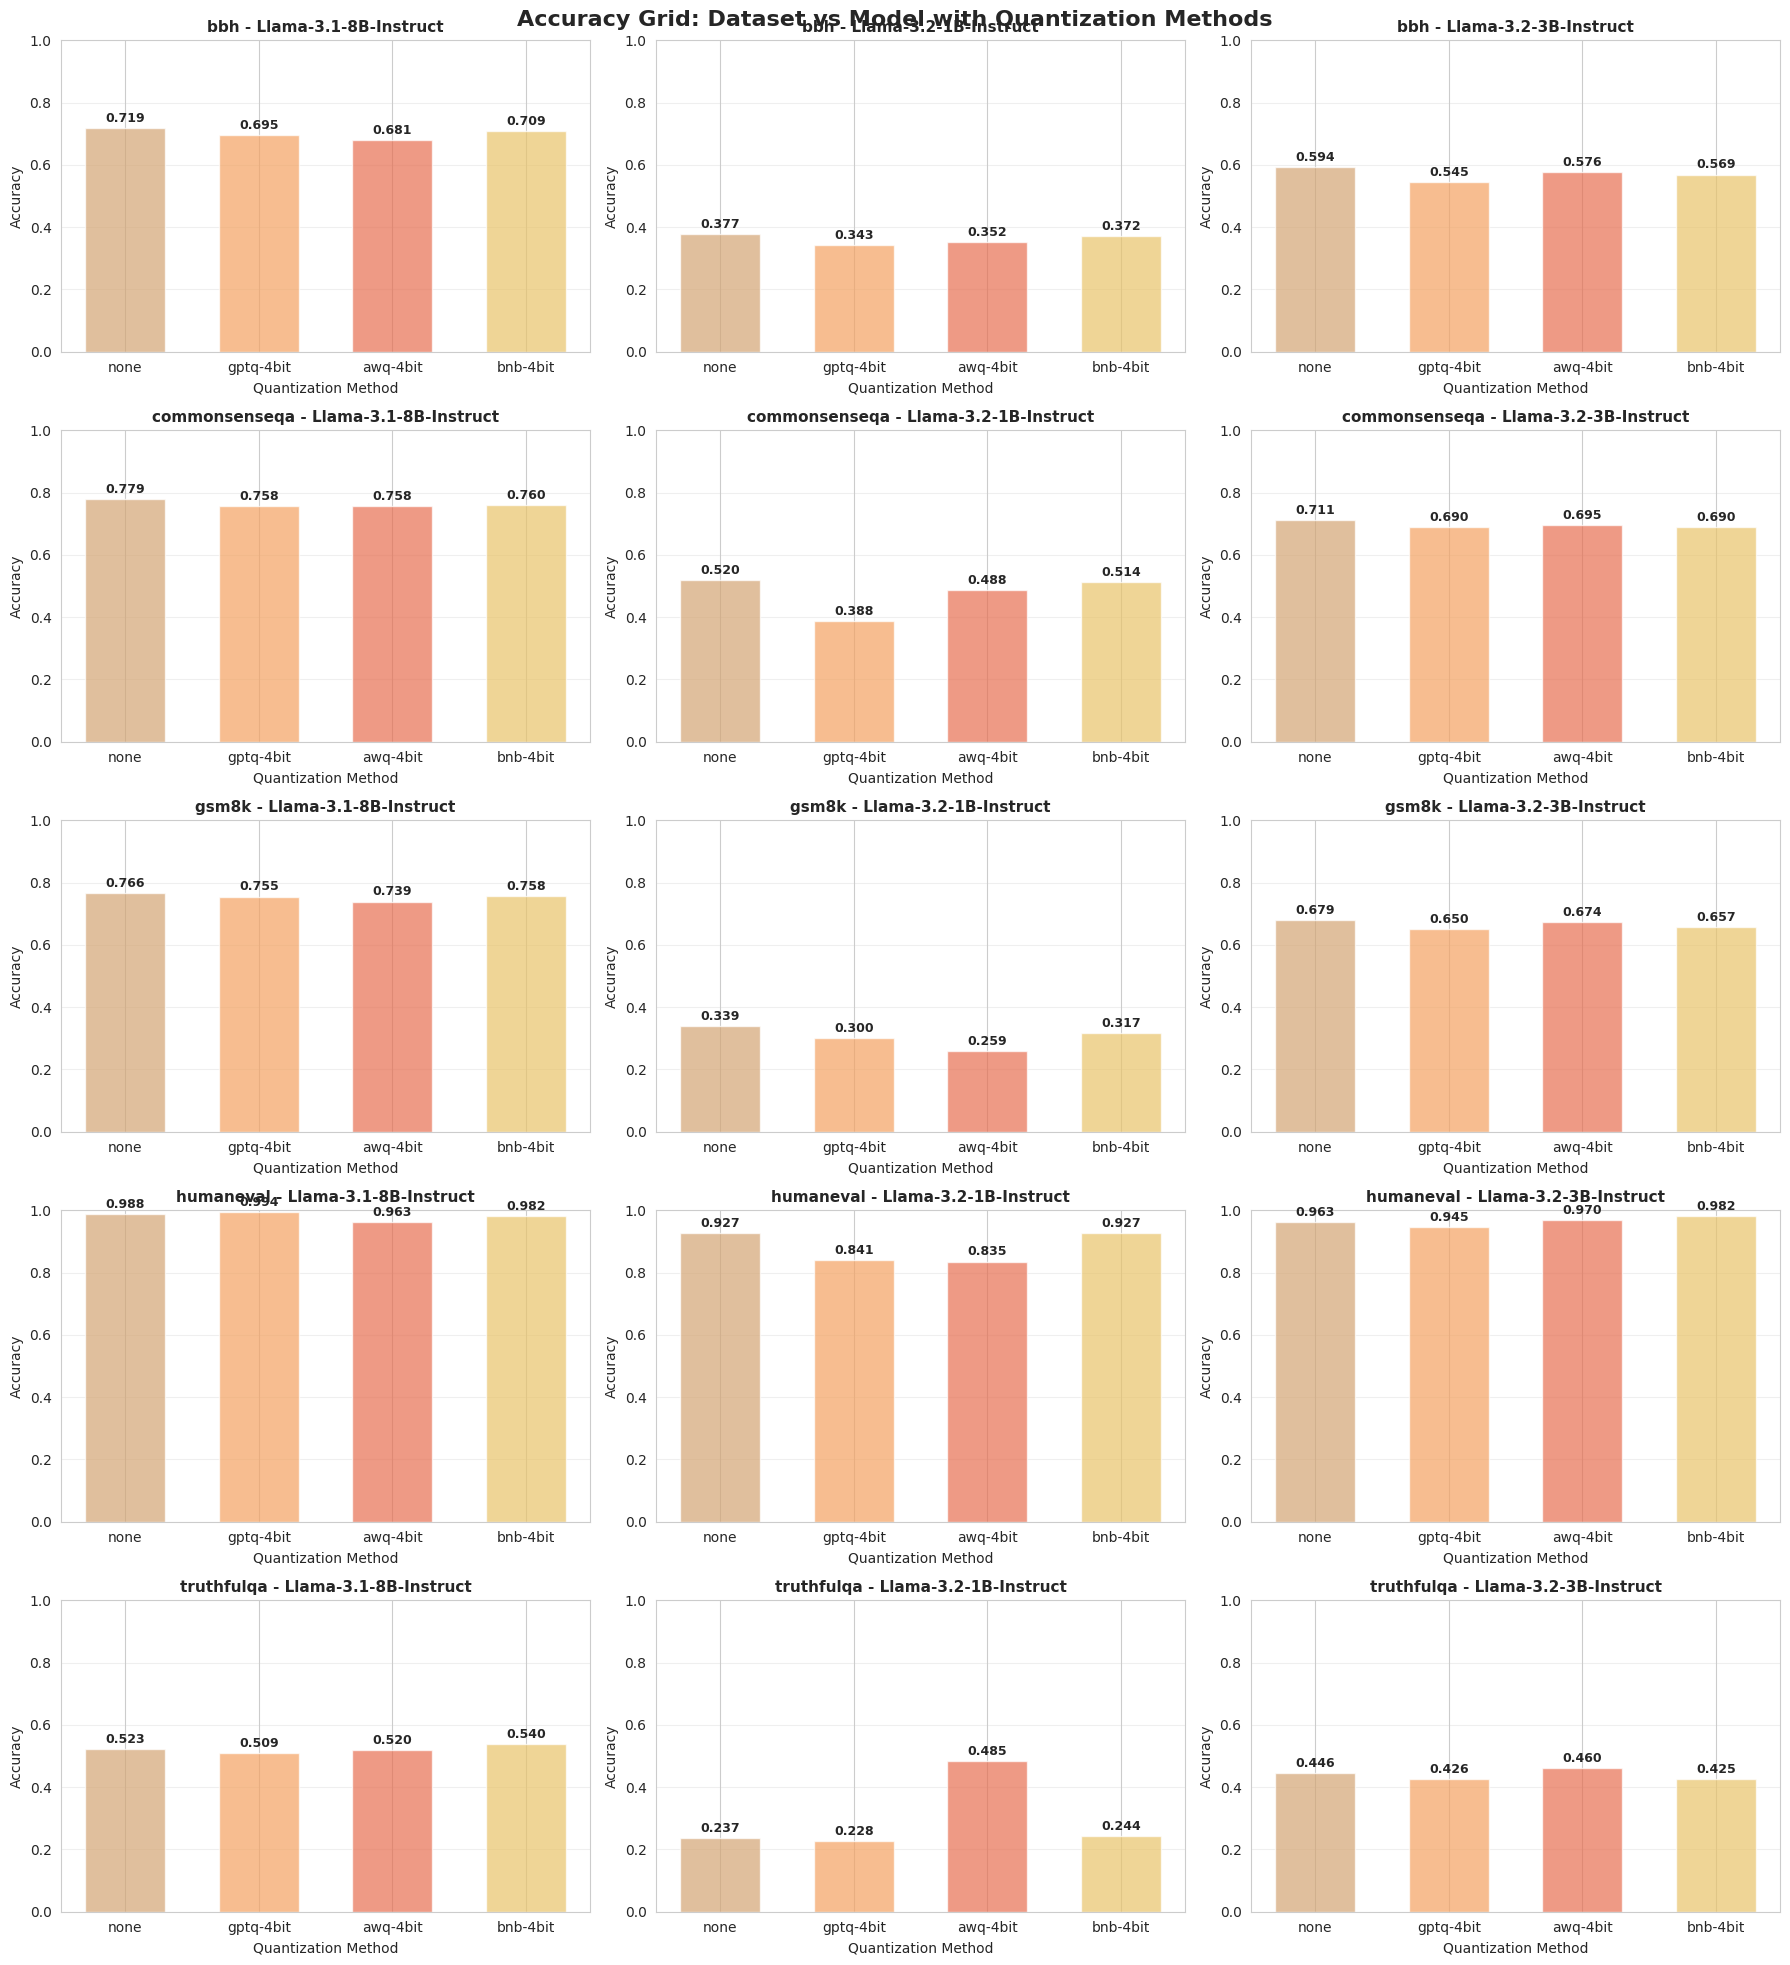

In [23]:
# Accuracy Grid Plot: Dataset vs Model with Quantization Methods
# 準確率網格圖：資料集 vs 模型，顯示量化方法

import matplotlib.pyplot as plt
import seaborn as sns

# Get unique datasets and models
datasets = sorted(df['dataset'].unique())
models = sorted(df['model_name'].unique())

# Create grid of subplots: rows = datasets, columns = models
fig, axes = plt.subplots(len(datasets), len(models), figsize=(6*len(models), 4*len(datasets)))
fig.suptitle('Accuracy Grid: Dataset vs Model with Quantization Methods', 
             fontsize=16, fontweight='bold', y=0.98)

# Handle single subplot case
if len(datasets) == 1 and len(models) == 1:
    axes = [[axes]]
elif len(datasets) == 1:
    axes = [axes]
elif len(models) == 1:
    axes = [[ax] for ax in axes]

for i, dataset in enumerate(datasets):
    for j, model in enumerate(models):
        ax = axes[i][j]
        
        # Filter data for this dataset and model
        df_subset = df[(df['dataset'] == dataset) & (df['model_name'] == model)]
        
        if len(df_subset) > 0:
            # Plot accuracy for each quantization method
            for quant in QUANT_ORDER:
                quant_data = df_subset[df_subset['quantization'] == quant]
                if len(quant_data) > 0:
                    acc = quant_data['accuracy'].values[0]
                    ax.bar(quant, acc, color=QUANT_COLORS.get(quant, 'gray'), alpha=0.7, width=0.6)
                    # Add value label on top of bar
                    ax.text(quant, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Formatting
        ax.set_title(f'{dataset} - {model}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Accuracy', fontsize=10)
        ax.set_xlabel('Quantization Method', fontsize=10)
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [24]:
# Accuracy Change Grid: Dataset vs Model with Quantization Methods (Percentage Change from Baseline)
# 準確率變化網格圖：資料集 vs 模型，顯示量化方法的百分比變化（相對於基準線）

import matplotlib.colors as mcolors

# Calculate baseline accuracy for each model-dataset pair (none quantization)
baseline_acc = df[df['quantization'] == 'none'].set_index(['model_name', 'dataset'])['accuracy']

# Calculate percentage changes for each quantized model
acc_changes = []

for model in df['model_name'].unique():
    for dataset in df['dataset'].unique():
        baseline = baseline_acc.get((model, dataset), None)
        if baseline is None or baseline == 0:
            continue
        
        for quant in ['gptq-4bit', 'awq-4bit', 'bnb-4bit']:
            quant_data = df[(df['model_name'] == model) & (df['dataset'] == dataset) & (df['quantization'] == quant)]
            if len(quant_data) == 0:
                continue
            
            quant_acc = quant_data['accuracy'].values[0]
            acc_change = ((quant_acc - baseline) / baseline) * 100
            
            acc_changes.append({
                'Dataset': dataset,
                'Model': model,
                'Quantization': quant,
                'Accuracy Change (%)': acc_change
            })

acc_changes_df = pd.DataFrame(acc_changes)

# Create styled DataFrame for each quantization method
if len(acc_changes_df) > 0:
    print("📊 Accuracy Change Grid: Percentage Change from Baseline (None)")
    print("="*80)
    
    # Define gradient styler for accuracy changes (Red-Green)
    def create_acc_change_styler(df):
        cmap = ['#CC0000', '#FFFFFF', '#006600']  # Dark red -> White -> Dark green
        custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom", cmap)
        return df.style.background_gradient(cmap=custom_cmap, axis=None, 
                                          vmin=-50, vmax=20).format('{:.1f}')
    
    # Create separate grids for each quantization method
    for quant in ['gptq-4bit', 'awq-4bit', 'bnb-4bit']:
        quant_df = acc_changes_df[acc_changes_df['Quantization'] == quant]
        if len(quant_df) > 0:
            # Pivot to create grid: rows=datasets, columns=models
            pivot_df = quant_df.pivot(index='Dataset', columns='Model', values='Accuracy Change (%)')
            
            print(f"\n🔹 {quant.upper()} - Accuracy Change (%) from Baseline")
            print("Red: Accuracy Loss | White: No Change | Green: Accuracy Gain")
            print("-" * 60)
            
            # Apply gradient styling
            styled_pivot = create_acc_change_styler(pivot_df)
            display(styled_pivot)
    
    # Summary statistics
    print("\n📈 Summary Statistics by Quantization Method:")
    summary = acc_changes_df.groupby('Quantization')['Accuracy Change (%)'].agg(['mean', 'min', 'max']).round(2)
    print(summary)

📊 Accuracy Change Grid: Percentage Change from Baseline (None)

🔹 GPTQ-4BIT - Accuracy Change (%) from Baseline
Red: Accuracy Loss | White: No Change | Green: Accuracy Gain
------------------------------------------------------------


Model,Llama-3.1-8B-Instruct,Llama-3.2-1B-Instruct,Llama-3.2-3B-Instruct
Dataset,,,
bbh,-3.3,-8.9,-8.2
commonsenseqa,-2.7,-25.4,-2.9
gsm8k,-1.4,-11.4,-4.2
humaneval,0.6,-9.2,-1.9
truthfulqa,-2.6,-4.1,-4.4



🔹 AWQ-4BIT - Accuracy Change (%) from Baseline
Red: Accuracy Loss | White: No Change | Green: Accuracy Gain
------------------------------------------------------------


Model,Llama-3.1-8B-Instruct,Llama-3.2-1B-Instruct,Llama-3.2-3B-Instruct
Dataset,,,
bbh,-5.3,-6.7,-3.0
commonsenseqa,-2.7,-6.1,-2.3
gsm8k,-3.5,-23.7,-0.7
humaneval,-2.5,-9.9,0.6
truthfulqa,-0.5,104.1,3.3



🔹 BNB-4BIT - Accuracy Change (%) from Baseline
Red: Accuracy Loss | White: No Change | Green: Accuracy Gain
------------------------------------------------------------


Model,Llama-3.1-8B-Instruct,Llama-3.2-1B-Instruct,Llama-3.2-3B-Instruct
Dataset,,,
bbh,-1.4,-1.3,-4.2
commonsenseqa,-2.4,-1.3,-3.0
gsm8k,-1.0,-6.5,-3.2
humaneval,-0.6,0.0,1.9
truthfulqa,3.3,2.6,-4.7



📈 Summary Statistics by Quantization Method:
              mean    min     max
Quantization                     
awq-4bit      2.74 -23.71  104.12
bnb-4bit     -1.46  -6.49    3.28
gptq-4bit    -6.00 -25.35    0.62
